# WorldCover API Demo

In [1]:
from shelterbelts.apis.worldcover import worldcover, worldcover_cmap, worldcover_labels

## Default Parameters
The default location is a ~2km x 2km region near Milgadara, NSW, Australia. It should take about 10 secs to load.

In [2]:
%%time
ds = worldcover()
ds

Starting worldcover.py
Saved: ./TEST_worldcover.tif
Saved: ./TEST_worldcover.png
CPU times: user 637 ms, sys: 125 ms, total: 762 ms
Wall time: 8.73 s


<xarray.Dataset> Size: 61kB
Dimensions:      (latitude: 240, longitude: 240)
Coordinates:
  * latitude     (latitude) float64 2kB -34.38 -34.38 -34.38 ... -34.4 -34.4
  * longitude    (longitude) float64 2kB 148.5 148.5 148.5 ... 148.5 148.5 148.5
    spatial_ref  int32 4B 4326
Data variables:
    worldcover   (latitude, longitude) uint8 58kB 30 30 30 30 30 ... 30 30 30 30

## Visualisating the results
You can view the results inside the notebook, or in preview as a PNG or TIF, or properly geolocated in QGIS.

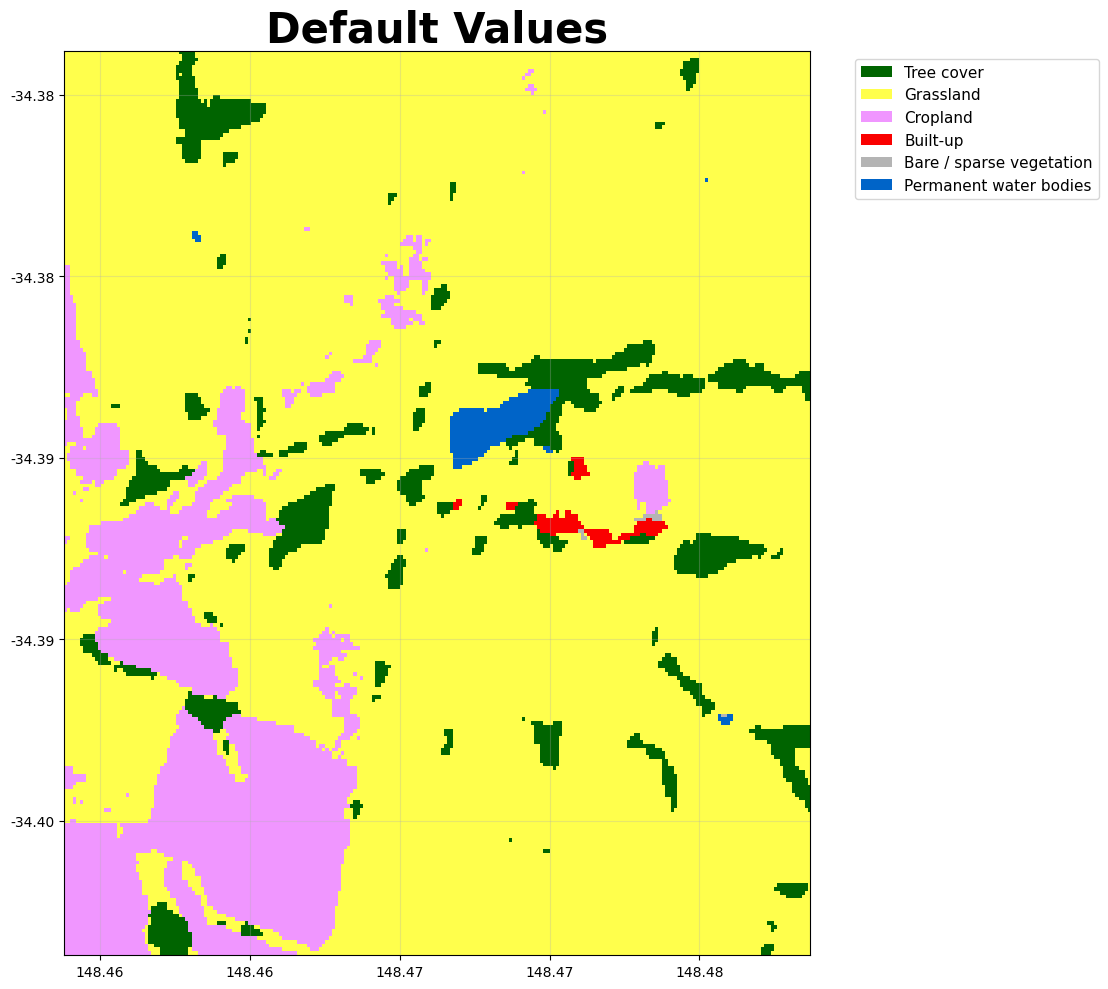

In [3]:
from shelterbelts.utils.visualisation import visualise_categories

visualise_categories(ds['worldcover'], colormap=worldcover_cmap, labels=worldcover_labels, title="Default Values")

## Changing Buffer Size
You can adjust the buffer parameter to change the size of the downloaded region. The buffer is in degrees (~1 degree ≈ 100 km depending on the latitude) in each direction from the centre point. A 10km x 10km region should take about 1 min to load.

Starting worldcover.py
Saved: ./TEST_worldcover.tif
Saved: ./TEST_worldcover.png


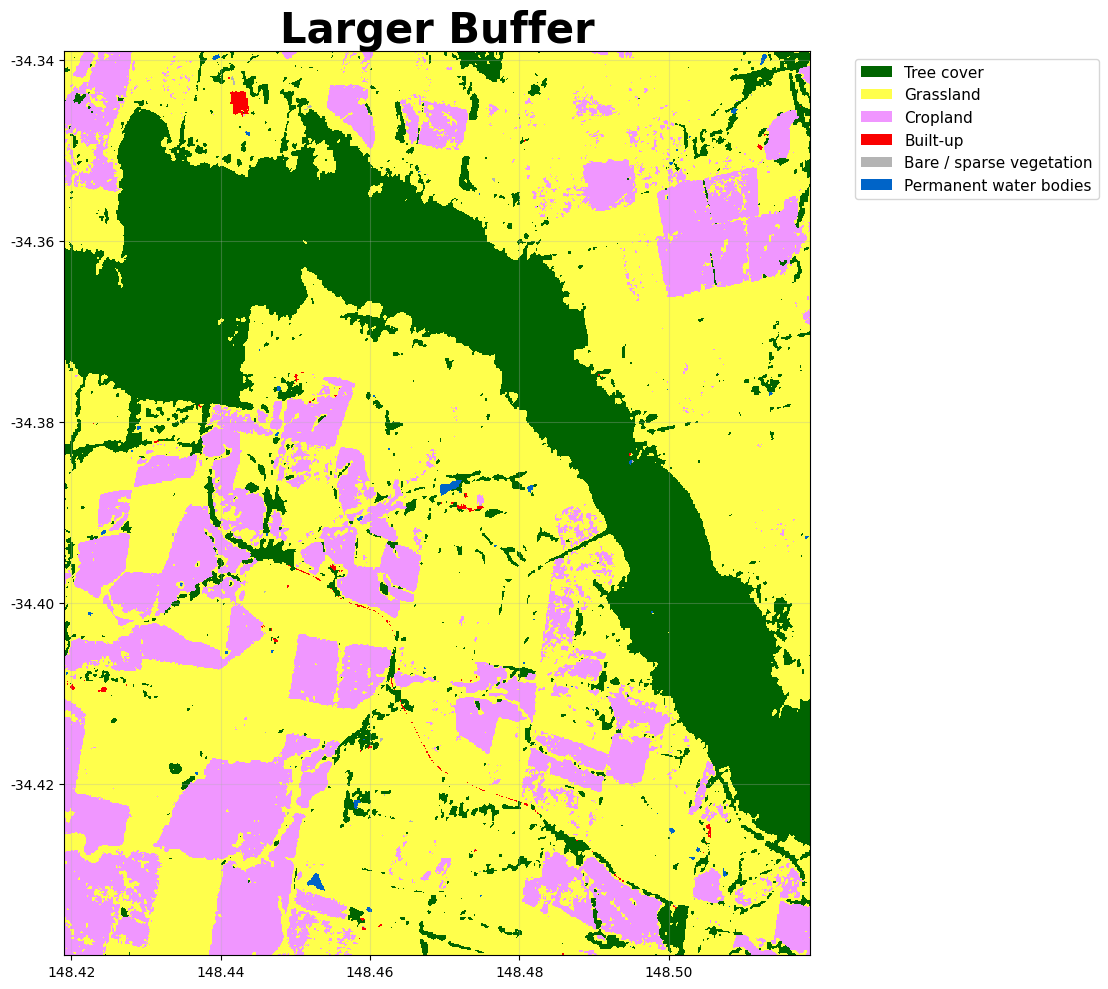

CPU times: user 1.37 s, sys: 349 ms, total: 1.72 s
Wall time: 5.01 s


In [4]:
%%time
ds_10km = worldcover(buffer=0.05)
visualise_categories(ds_10km['worldcover'], colormap=worldcover_cmap, labels=worldcover_labels, title="Larger Buffer")

## Changing Location
Use the lat and lon arguments to download data for a different location. Here is an example of ANU in Canberra.

Starting worldcover.py
Saved: ./TEST_worldcover.tif
Saved: ./TEST_worldcover.png


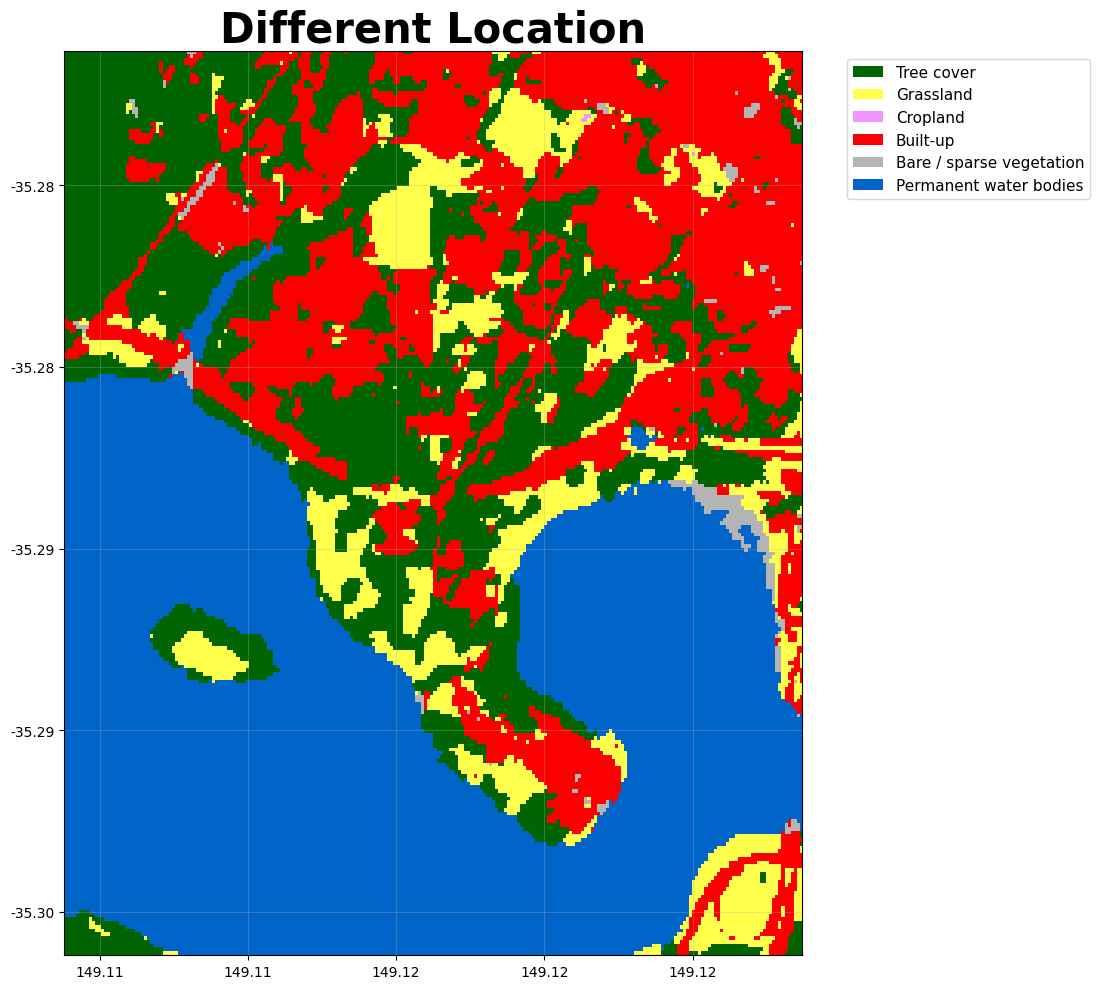

In [5]:
ds_canberra = worldcover(lat=-35.287, lon=149.117)
visualise_categories(ds_canberra['worldcover'], colormap=worldcover_cmap, labels=worldcover_labels, title="Different Location")

## Changing Output Directory
Specify a custom output directory for the saved files.

In [6]:
import os
outdir = "outdir"
os.makedirs(outdir, exist_ok=True)
ds = worldcover(outdir=outdir)

Starting worldcover.py
Saved: outdir/TEST_worldcover.tif
Saved: outdir/TEST_worldcover.png


## Changing Filename Prefix
Choose a stub to be used as the prefix for output filenames.

In [7]:
ds = worldcover(stub="DEMO", outdir=outdir)

Starting worldcover.py
Saved: outdir/DEMO_worldcover.tif
Saved: outdir/DEMO_worldcover.png


## Disabling GeoTIFF Output
Set `save_tif=False` to skip saving the GeoTIFF file and only keep the dataset in memory. Useful for when running within a larger pipeline.

In [8]:
ds = worldcover(save_tif=False)

Starting worldcover.py
Saved: ./TEST_worldcover.png


## Disabling Visualisation Plot
Set `plot=False` to skip generating and saving the PNG visualisation. This can be used in combination with `save_tif=False` to avoid any outputs.

In [9]:
ds = worldcover(plot=False)

Starting worldcover.py
Saved: ./TEST_worldcover.tif


## Command Line Interface
You can also use the function from the command line with the same defaults and parameters.

In [10]:
!python -m shelterbelts.apis.worldcover --help

usage: worldcover.py [-h] [--lat LAT] [--lon LON] [--buffer BUFFER]
                     [--outdir OUTDIR] [--stub STUB] [--no-save-tif]
                     [--no-plot]

options:
  -h, --help       show this help message and exit
  --lat LAT        Latitude in EPSG:4326 (default: -34.389)
  --lon LON        Longitude in EPSG:4326 (default: 148.469)
  --buffer BUFFER  Buffer in each direction in degrees (default: 0.01 ≈ 1 km)
  --outdir OUTDIR  Output directory for saving results (default: current
                   directory)
  --stub STUB      Prefix for output filenames (default: TEST)
  --no-save-tif    Disable saving GeoTIFF output (default: enabled)
  --no-plot        Disable PNG visualisation (default: enabled)


In [11]:
!python -m shelterbelts.apis.worldcover

Starting worldcover.py
Saved: ./TEST_worldcover.tif
Saved: ./TEST_worldcover.png


In [12]:
!python -m shelterbelts.apis.worldcover --lat -35.287 --lon 149.117 --buffer 0.02 --stub command_line

Starting worldcover.py
Saved: ./command_line_worldcover.tif
Saved: ./command_line_worldcover.png


### Cleanup
Remove the output files created by this notebook

In [13]:
# !rm *.tif
# !rm *.png